# Image Classification with Transformers
### Authors: Cole Drumheller and Joseph Doty

In [161]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as T
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 1337
torch.manual_seed(seed)

# Hyperparameters

img_size = 32            # CIFAR-10 images are 32x32
patch_size = 2        # 4x4 patches -> (32/4)^2 = 64 tokens | 2x2 patches = 256 tokens | 8x8 patches = 16 tokens
in_chans = 3
num_classes = 10

# model capacity
embed_dim = 192
num_heads = 6
mlp_ratio = 4
num_layers = 6
dropout = 0.1

# training
batch_size = 128
epochs = 20
lr = 3e-4
weight_decay = 0.05

# misc
save_dir = "./vit_cifar"
os.makedirs(save_dir, exist_ok=True)

In [ ]:

# Data: CIFAR-10
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    #T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)), original weights
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = T.Compose([
    T.ToTensor(),
    #T.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_ds = torchvision.datasets.CIFAR10(root=".", train=True, download=True, transform=transform_train)
test_ds = torchvision.datasets.CIFAR10(root=".", train=False, download=True, transform=transform_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:

# ViT components
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_chans, embed_dim):
        super().__init__()
        assert img_size % patch_size == 0, "Image size must be divisible by patch size"
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        # Use a conv layer to produce patch embeddings
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x: (B, C, H, W)
        x = self.proj(x)                # (B, embed_dim, H/ps, W/ps)
        x = x.flatten(2)                # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)           # (B, num_patches, embed_dim)
        return x

In [165]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, in_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [166]:
class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, return_attn=False):
        B, N, C = x.shape
        qkv = self.qkv(x)                      
        qkv = qkv.reshape(B, N, 3, self.num_heads, C // self.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)       
        q, k, v = qkv[0], qkv[1], qkv[2] # extract the query, key, and value matrices

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1) # perform softmax on query key comparison
        attn = self.attn_drop(attn)

        out = (attn @ v)                       
        out = out.transpose(1, 2).reshape(B, N, C)
        out = self.proj(out)
        out = self.proj_drop(out)

        if return_attn:
            return out, attn # returns raw attention weights for visualizations
        return out

In [167]:
class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, num_heads=num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(dim, hidden_dim, dropout=dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self,
                 img_size=32,
                 patch_size=4,
                 in_chans=3,
                 num_classes=10,
                 embed_dim=192,
                 depth=6,
                 num_heads=6,
                 mlp_ratio=4.0,
                 dropout=0.1):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_chans, embed_dim)
        num_patches = self.patch_embed.num_patches

        # class token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)

        # transformer encoder
        self.blocks = nn.ModuleList([
            Block(embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Linear(embed_dim, num_classes)

        # init
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=0.02)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.LayerNorm):
            nn.init.zeros_(m.bias)
            nn.init.ones_(m.weight)

    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)             # (B, num_patches, embed_dim)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B,1,embed_dim)
        x = torch.cat((cls_tokens, x), dim=1)           # (B, 1+num_patches, embed_dim)
        x = x + self.pos_embed
        x = self.pos_drop(x)

        # for visualizatoin of attention
        # start with empty list of maps
        attention_maps = []
        for blk in self.blocks:
            if hasattr(blk, 'attn'):
                if getattr(self, "_return_attn", False):
                    x_norm = blk.norm1(x)
                    attn_out, attn = blk.attn(x_norm, return_attn=True)
                    x = x + attn_out
                    x = x + blk.mlp(blk.norm2(x))
                    # add this layer of attention weights to the map
                    attention_maps.append(attn.detach().cpu())
                else:
                    
                    x = blk(x)
            else:
                x = blk(x)

        x = self.norm(x)
        cls = x[:, 0]                       # take cls token
        out = self.head(cls)

        if getattr(self, "_return_attn", False):
            return out, attention_maps # return the attention map data for visualizatoin

        return out

In [169]:
# ---------------------------
# Instantiate model, loss, optimizer
# ---------------------------
model = VisionTransformer(
    img_size=img_size,
    patch_size=patch_size,
    in_chans=in_chans,
    num_classes=num_classes,
    embed_dim=embed_dim,
    depth=num_layers,
    num_heads=num_heads,
    mlp_ratio=mlp_ratio,
    dropout=dropout
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs * len(train_loader))

In [ ]:

# Training & evaluation 
def train_one_epoch(epoch):
    model.train()
    pbar = tqdm(train_loader, desc=f"Train {epoch}")
    total_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        logits = model(imgs)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix(loss=total_loss / total, acc=correct/total)

    return total_loss / total, correct / total

def evaluate():
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            logits = model(imgs)
            loss = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

In [ ]:

# Run the training
train_losses = []
train_accs = []
val_losses = []
val_accs = []

best_val_acc = 0.0
# loop thorugh all epochs
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(epoch)
    val_loss, val_acc = evaluate()

    # build lists for matplotlib output
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    # save best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch
        }, os.path.join(save_dir, "best_vit.pth"))
        print(f"Saved best model (val_acc={best_val_acc:.4f})")

Train 1: 100%|██████████| 391/391 [00:47<00:00,  8.29it/s, acc=0.294, loss=1.88]


Epoch 1: train_loss=1.8751 train_acc=0.2935 | val_loss=1.7085 val_acc=0.3659
Saved best model (val_acc=0.3659)


Train 2: 100%|██████████| 391/391 [00:47<00:00,  8.23it/s, acc=0.428, loss=1.55]


Epoch 2: train_loss=1.5475 train_acc=0.4285 | val_loss=1.3644 val_acc=0.5085
Saved best model (val_acc=0.5085)


Train 3: 100%|██████████| 391/391 [00:47<00:00,  8.22it/s, acc=0.5, loss=1.37]  


...

Epoch 18: train_loss=0.7498 train_acc=0.7343 | val_loss=0.7861 val_acc=0.7254
Saved best model (val_acc=0.7254)


Train 19: 100%|██████████| 391/391 [00:48<00:00,  8.14it/s, acc=0.736, loss=0.739]


Epoch 19: train_loss=0.7391 train_acc=0.7358 | val_loss=0.7831 val_acc=0.7274
Saved best model (val_acc=0.7274)


Train 20: 100%|██████████| 391/391 [00:48<00:00,  8.11it/s, acc=0.739, loss=0.734]


Epoch 20: train_loss=0.7345 train_acc=0.7387 | val_loss=0.7829 val_acc=0.7262


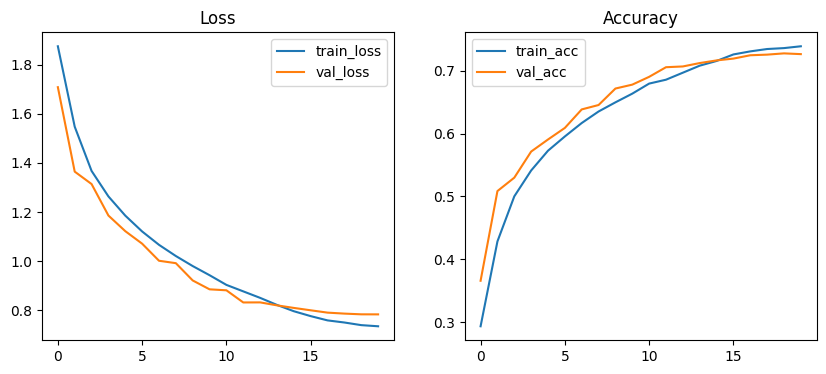

Best validation accuracy: 0.7274


In [172]:
# ---------------------------
# Plot metrics
# ---------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_accs, label="train_acc")
plt.plot(val_accs, label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

print("Best validation accuracy:", best_val_acc)

In [173]:
# look at visualizations
#state = torch.load("./vit_cifar/600epochs.pth", map_location='cpu')
#model.load_state_dict(state["model_state"])

model.eval()
model._return_attn = True

imgs, labels = next(iter(test_loader))
img = imgs[0:10].to(device)

with torch.no_grad():
    logits, attn_maps = model(img)

with torch.no_grad():
    predictions = logits.argmax(1)



print(f"Predicted: {predictions.cpu().numpy()}")
print(f"Actual: {labels.numpy()[0:10]}")


Predicted: [3 8 8 0 6 6 1 6 3 1]
Actual: [3 8 8 0 6 6 1 6 3 1]


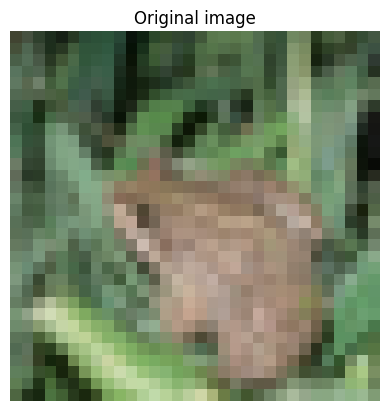

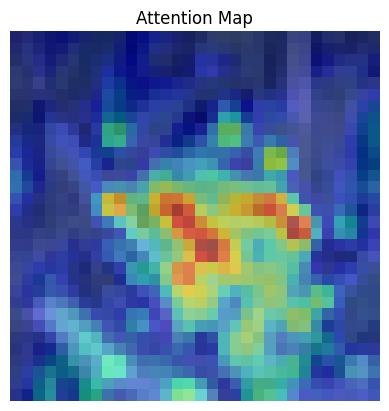

In [174]:
img_num = 4

cls_attn = attn_maps[-1][img_num,:,0,1:] # [-1] grabs final layer of attention values, [img#, all heads (:), cls token distribution (0), skip over cls token in keys (1:)]
num_patches = (img_size // patch_size) ** 2
grid_size = int(math.sqrt(num_patches))
cls_attn_map = cls_attn.mean(0).reshape(grid_size, grid_size)
cls_attn_map = cls_attn_map / cls_attn_map.max()

attn_resized = F.interpolate(
    cls_attn_map.unsqueeze(0).unsqueeze(0),
    size=(img_size, img_size),
    mode='bilinear'
)[0,0].cpu()

def denorm(x):
    mean = torch.tensor((0.5, 0.5, 0.5), device=x.device).view(3,1,1)
    std = torch.tensor((0.5, 0.5, 0.5), device = x.device).view(3,1,1)
    return x * std + mean

img_vis = denorm(img[img_num]).permute(1,2,0).cpu()

plt.imshow(img_vis)
plt.title('Original image')
plt.axis('off')
plt.show()

plt.imshow(img_vis)
plt.imshow(attn_resized, cmap='jet', alpha=0.5)
plt.title('Attention Map')
plt.axis('off')
plt.show()

# Red = most attention
# blue = least attention